In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [3]:
train_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,social_support,peer_pressure,extracurricular_activities,bullying,target,mental_health_score,physical_score,environment_score,academic_score,social_score
0,0.314428,0.795832,1,-0.333345,-0.349524,-1.430923,-0.426886,-0.521307,-0.489063,-0.462047,...,0.118375,0.187084,0.163779,-0.413484,1,0.444229,-0.682160,-0.330784,-0.119688,0.013938
1,1.282463,-0.771658,1,1.611905,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.837312,1.594209,1.563055,1.549820,2,0.780678,0.652823,-0.339384,0.052696,0.967443
2,-1.621643,0.795832,0,-1.241128,-1.064830,-0.225935,1.516182,-1.236986,-1.240155,1.317391,...,1.074062,-1.220041,-0.535859,-1.067918,0,-0.516735,-0.252892,0.630892,-0.116037,-0.437439
3,0.637107,-0.883621,1,0.574438,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.837312,1.594209,0.863417,1.549820,2,0.331981,0.652823,-0.339384,0.063244,0.792533
4,-0.653607,1.019759,0,-1.630178,-1.064830,-0.225935,0.868493,-0.521307,-0.489063,0.427672,...,1.074062,-0.516479,-1.235497,-1.067918,0,-0.316007,-0.235895,0.596235,-0.116037,-0.436458


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 880 non-null    float64
 1   self_esteem                   880 non-null    float64
 2   mental_health_history         880 non-null    int64  
 3   depression                    880 non-null    float64
 4   headache                      880 non-null    float64
 5   blood_pressure                880 non-null    float64
 6   sleep_quality                 880 non-null    float64
 7   breathing_problem             880 non-null    float64
 8   noise_level                   880 non-null    float64
 9   living_conditions             880 non-null    float64
 10  safety                        880 non-null    float64
 11  basic_needs                   880 non-null    float64
 12  academic_performance          880 non-null    float64
 13  study

In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 220 non-null    float64
 1   self_esteem                   220 non-null    float64
 2   mental_health_history         220 non-null    int64  
 3   depression                    220 non-null    float64
 4   headache                      220 non-null    float64
 5   blood_pressure                220 non-null    float64
 6   sleep_quality                 220 non-null    float64
 7   breathing_problem             220 non-null    float64
 8   noise_level                   220 non-null    float64
 9   living_conditions             220 non-null    float64
 10  safety                        220 non-null    float64
 11  basic_needs                   220 non-null    float64
 12  academic_performance          220 non-null    float64
 13  study

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
feature_cols = [c for c in train_df.columns if c != "target"]

X_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [8]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        74
           1       0.88      0.90      0.89        72
           2       0.89      0.89      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [ ]:
# RF - 89%

In [ ]:
#so moving on to hyperparameter tuning using GridSearch

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [11]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [12]:
grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF CV accuracy:", grid_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best RF CV accuracy: 0.8863636363636364


In [13]:
best_rf = grid_rf.best_estimator_
tuned_rf_preds = best_rf.predict(x_test)
tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_preds)

In [14]:
print("Tuned RF Test Accuracy:", tuned_rf_accuracy)
print(classification_report(y_test, tuned_rf_preds))

Tuned RF Test Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.90      0.89      0.90        74
           1       0.93      0.90      0.92        72
           2       0.87      0.91      0.89        74

    accuracy                           0.90       220
   macro avg       0.90      0.90      0.90       220
weighted avg       0.90      0.90      0.90       220



In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

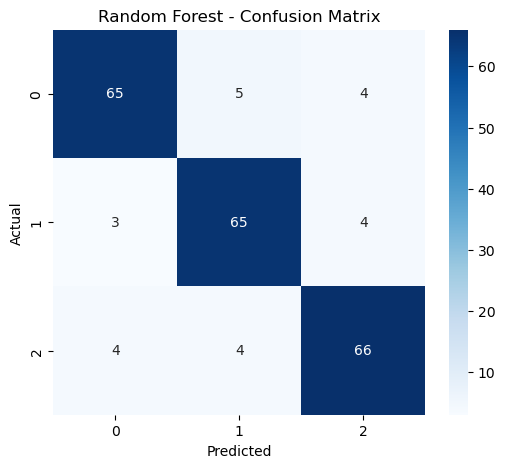

In [16]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest CV scores:", rf_cv)
print("Mean CV accuracy:", rf_cv.mean(), "Std:", rf_cv.std())

Random Forest CV scores: [0.89772727 0.88636364 0.89204545 0.85795455 0.86363636]
Mean CV accuracy: 0.8795454545454545 Std: 0.0158277139513456


In [18]:
#saving the model
import joblib

In [19]:
joblib.dump(best_rf, "../results/model_trained_files/random_forest_model.pkl")

['../results/model_trained_files/random_forest_model.pkl']